<a href="https://colab.research.google.com/github/gaduhprakoso/PCVK_Ganjil2026/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM FILTER**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
#C. membuat fungsi konvolusi

def convolution2d(image, kernel, stride=1, padding=0):

    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    h_img, w_img = image.shape
    h_kernel, w_kernel = kernel.shape

    out_h = ((h_img - h_kernel) // stride) + 1
    out_w = ((w_img - w_kernel) // stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for y in range(0, out_h):
        for x in range(0, out_w):
            roi = image[y*stride:y*stride+h_kernel, x*stride:x*stride+w_kernel]
            output[y, x] = np.sum(roi * kernel)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

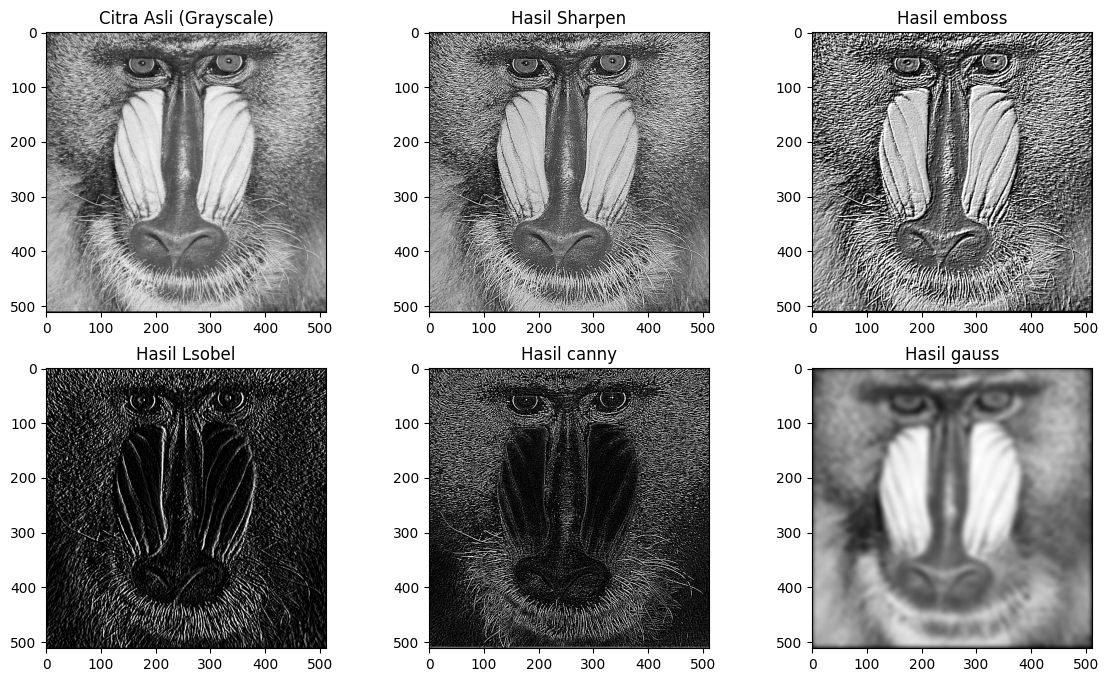

In [12]:
img = cv.imread('/content/mandrill.tiff')

img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

#sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

#emboss
kernel_emboss = np.array([[-2, -1,  0],
                          [-1,  1,  1],
                          [ 0,  1,  2]])

#Left Sobel Edge Detection
kernel_Lsobel = np.array([[ 1,  0,  -1],
                        [ 2,  0,  -2],
                        [ 1,  0,  -1]])

#Canny Edge Detection
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

# Gassuan Blur 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

hasil_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
hasil_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
hasil_Lsobel = convolution2d(img_gray, kernel_Lsobel, stride=1, padding=1)
hasil_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
hasil_gauss = convolution2d(img_gray, gauss_kernel, stride=1, padding=kernel_size // 2)

plt.figure(figsize=(14, 8))
plt.subplot(2, 3, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Citra Asli (Grayscale)')
plt.subplot(2, 3, 2), plt.imshow(hasil_sharpen, cmap='gray'), plt.title('Hasil Sharpen')
plt.subplot(2, 3, 3), plt.imshow(hasil_emboss, cmap='gray'), plt.title('Hasil emboss')
plt.subplot(2, 3, 4), plt.imshow(hasil_Lsobel, cmap='gray'), plt.title('Hasil Lsobel')
plt.subplot(2, 3, 5), plt.imshow(hasil_canny, cmap='gray'), plt.title('Hasil canny')
plt.subplot(2, 3, 6), plt.imshow(hasil_gauss, cmap='gray'), plt.title('Hasil gauss')
plt.show()

E. FILTER LIBRARY DAN FILTER MODERN

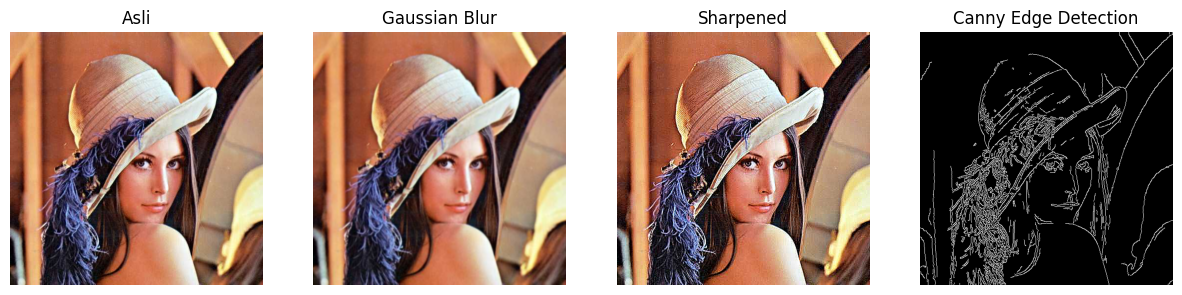

In [13]:
#percobaan 1

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

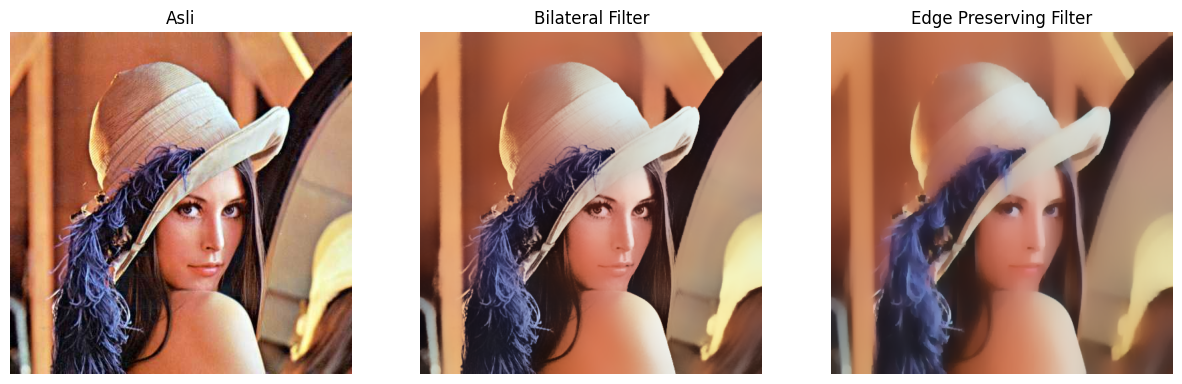

In [14]:
#percobaan 2

# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

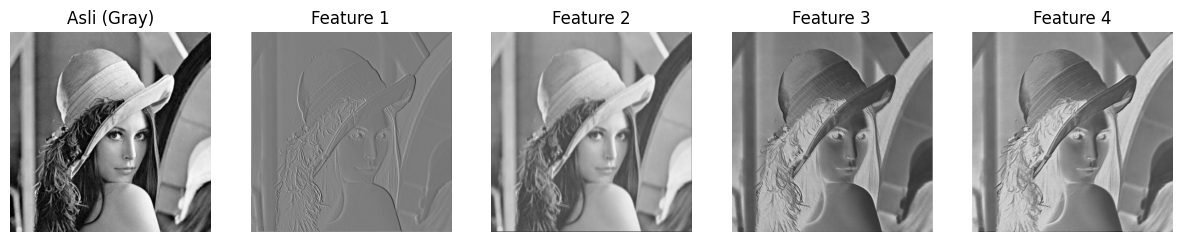

In [15]:
#percobaan 3

# Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

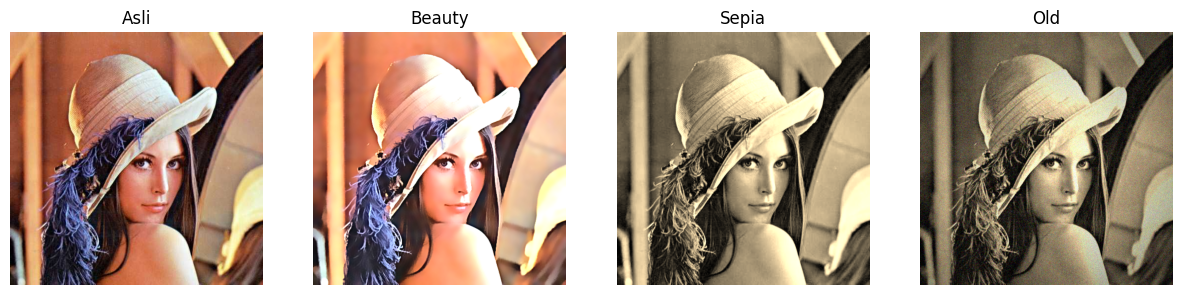

In [18]:
#percobaan 4

# ==========================
# 1. Beauty Filter
# ==========================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# ==========================
# 2. Old/Vintage Filter
# ==========================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                          [0.349, 0.686, 0.168],
                          [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, sepia, old_img],
                  ["Asli", "Beauty", "Sepia", "Old"])

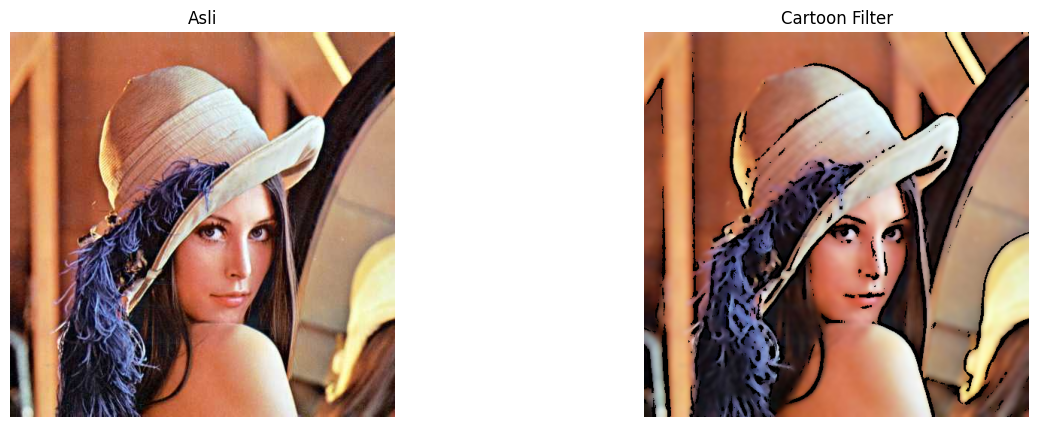

In [19]:
#percobaan 5

# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                            cv.ADAPTIVE_THRESH_MEAN_C,
                            cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

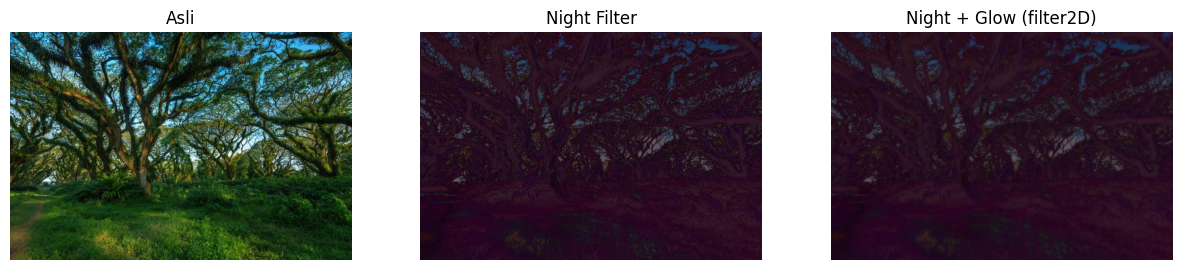

In [33]:
#percobaan 6

#Night Filter
img = cv.imread("/content/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

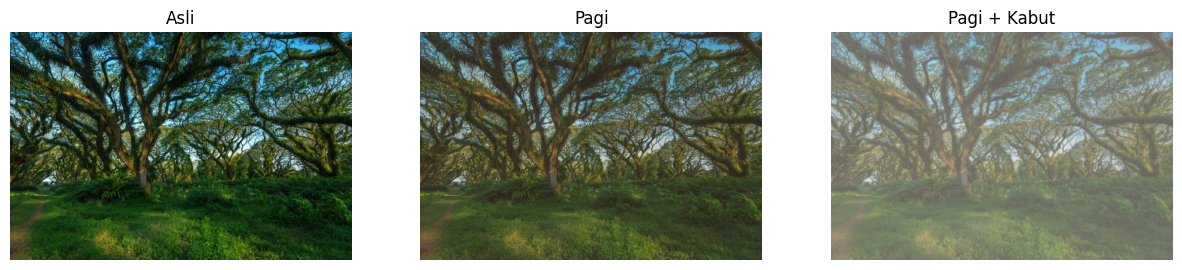

In [21]:
#percobaan 7

#Filter Suasana pagi dan Kabut
# ==========================
# Step 1: Kurangi kontras & cerahkan
# ==========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

**Tugas Praktikum**

In [37]:
img = cv.imread("/content/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

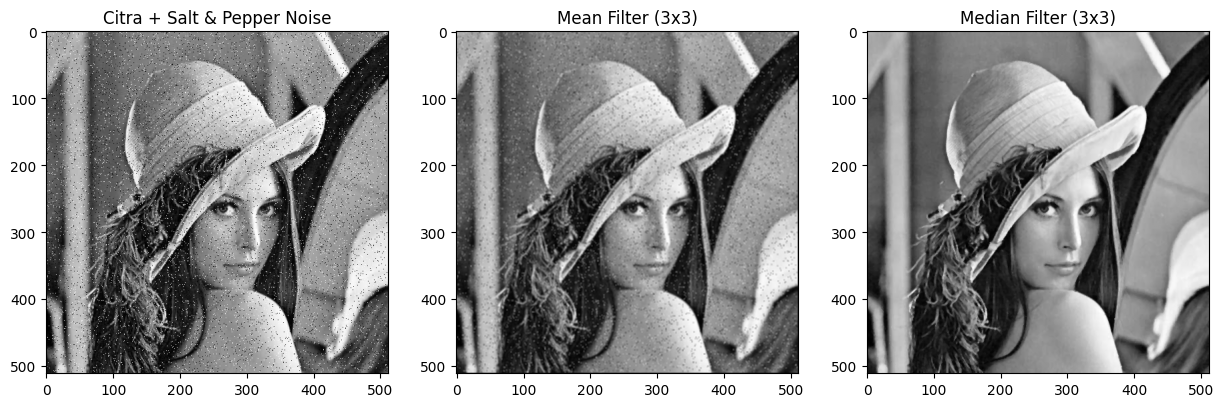

In [42]:
#Tugas Analisis

def add_salt_and_pepper(image, prob):
    noisy = image.copy()
    # Menambahkan Salt (putih = 255)
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Menambahkan Pepper (hitam = 0)
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

def median_filter_2d(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='edge')
    out = np.zeros_like(image)
    h, w = image.shape
    for i in range(h):
        for j in range(w):
            roi = padded[i:i+kernel_size, j:j+kernel_size]
            out[i, j] = np.median(roi)
    return out.astype(np.uint8)

img_noisy = add_salt_and_pepper(img_gray, prob=0.05)
kernel_mean = np.ones((3,3), dtype=np.float32) / 9.0
img_mean = convolution2d(img_noisy, kernel_mean, stride=1, padding=1)
img_median = median_filter_2d(img_noisy, kernel_size=3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_noisy, cmap='gray'), plt.title('Citra + Salt & Pepper Noise')
plt.subplot(1, 3, 2), plt.imshow(img_mean, cmap='gray'), plt.title('Mean Filter (3x3)')
plt.subplot(1, 3, 3), plt.imshow(img_median, cmap='gray'), plt.title('Median Filter (3x3)')
plt.show()

Analisis Visual:

* Median Filter jauh lebih unggul dalam membersihkan salt and pepper noise karena nilai ekstrem (0 atau 255) diabaikan dan digantikan oleh nilai tengah (median) dari area tetangga.

* Mean Filter cenderung merata-rata nilai piksel tetangga termasuk nilai noise ekstrem tersebut, sehingga membuat noise tampak menyebar (blur/bercak abu-abu) alih-alih hilang sepenuhnya.

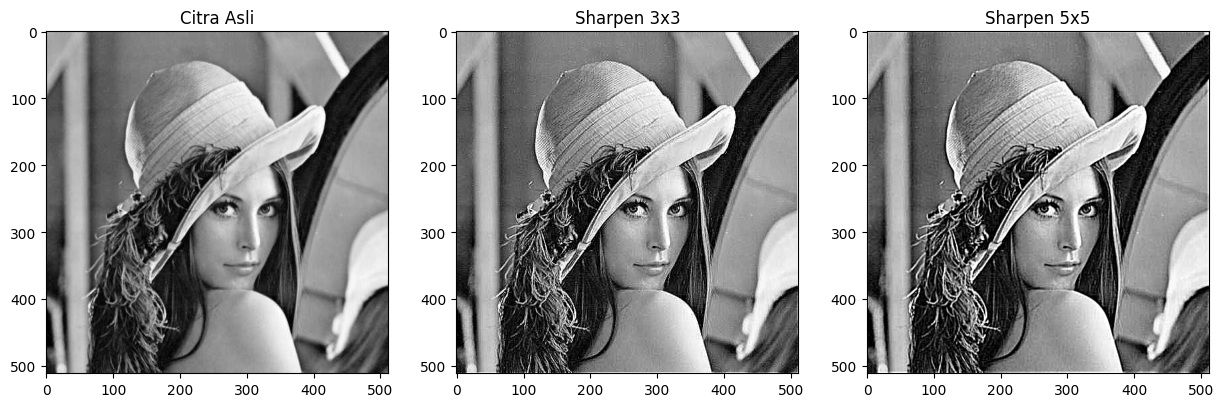

In [41]:
#Tugas Evaluasi

# kernel sharpen 3x3 dan 5x5
kernel_3x3 = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])

kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                       [-1,  1,  1,  1, -1],
                       [-1,  1, 16,  1, -1],
                       [-1,  1,  1,  1, -1],
                       [-1, -1, -1, -1, -1]])

kernel_5x5 = kernel_5x5 / np.sum(kernel_5x5) if np.sum(kernel_5x5) != 0 else kernel_5x5

out_3x3 = convolution2d(img_gray, kernel_3x3, stride=1, padding=1)
out_5x5 = convolution2d(img_gray, kernel_5x5, stride=1, padding=2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Citra Asli')
plt.subplot(1, 3, 2), plt.imshow(out_3x3, cmap='gray'), plt.title('Sharpen 3x3')
plt.subplot(1, 3, 3), plt.imshow(out_5x5, cmap='gray'), plt.title('Sharpen 5x5')
plt.show()

Evaluasi & Kesimpulan:

* Kernel 3x3 memberikan penajaman yang seimbang (optimal untuk penggunaan sehari-hari) karena memperjelas garis tepi tanpa terlalu memperkuat distorsi atau noise.

* Kernel 5x5 menghasilkan penajaman yang terlalu agresif (oversharpening) dan rentan memperbesar artefak atau noise latar belakang pada citra.

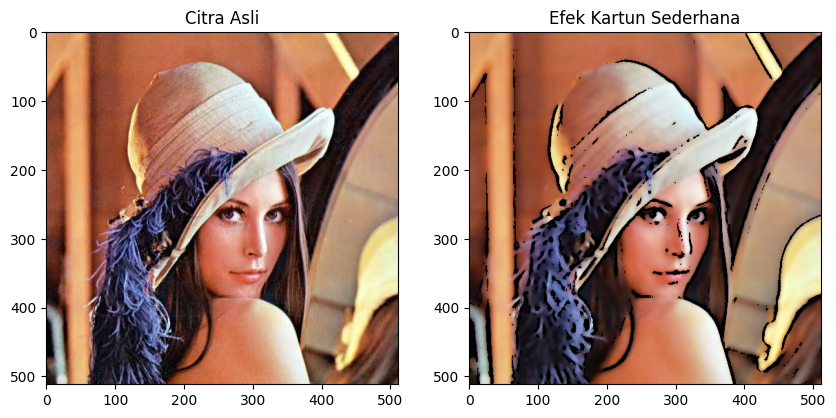

In [43]:
#Tugas Kreasi

def kartun(image):

    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                  cv.ADAPTIVE_THRESH_MEAN_C,
                                  cv.THRESH_BINARY, 9, 9)

    edges_colored = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    cartoon_out = cv.bitwise_and(color, edges_colored)
    return cartoon_out

img_bgr = cv.cvtColor(img, cv.COLOR_RGB2BGR)
hasil_kartun = kartun(img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) if len(img.shape)==3 else img, cmap='gray'), plt.title('Citra Asli')
plt.subplot(1, 2, 2), plt.imshow(cv.cvtColor(hasil_kartun, cv.COLOR_BGR2RGB)), plt.title('Efek Kartun Sederhana')
plt.show()